In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import trapezoid
import warnings; warnings.filterwarnings('ignore')

import qutip as qt
print(f'QuTiP    {qt.__version__}')

import pennylane as qml
print(f'PennyLane {qml.__version__}')

import scipy
print(f'NumPy  {np.__version__}   SciPy  {scipy.__version__}')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})


QuTiP    5.2.3
PennyLane 0.44.1
NumPy  2.4.3   SciPy  1.17.1


# State Preparation

creating a perfect Bell state (where in the paper F = 0.91, C = 0.89)

In [2]:
Phi_plus = qt.bell_state('00')
Psi_plus = qt.bell_state('10')   # paper: Q up, A down superposition

print('Psi+ =', Psi_plus.trans())
print(f'Concurrence of |Psi+>: {qt.concurrence(qt.ket2dm(Psi_plus)):.6f}')

# Initial 3-qubit state: Q-A in Bell state, E in ground state |0>
e_ground = qt.basis(2, 0)
psi0_3q  = qt.tensor(Psi_plus, e_ground)
rho0_3q  = qt.ket2dm(psi0_3q)

print(f'\nrho0_3q dims: {rho0_3q.dims}')
print(f'Tr(rho0)  = {rho0_3q.tr():.6f}  (must be 1)')
print(f'Tr(rho0^2) = {(rho0_3q**2).tr():.6f} (1 = pure state)')

# Verify Q-A partial trace recovers the Bell state
rho_QA_init = rho0_3q.ptrace([0, 1])
print(f'C(rho_QA at t=0) = {qt.concurrence(rho_QA_init):.6f}')

Psi+ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[0.         0.70710678 0.70710678 0.        ]]
Concurrence of |Psi+>: 1.000000

rho0_3q dims: [[2, 2, 2], [2, 2, 2]]
Tr(rho0)  = 1.000000  (must be 1)
Tr(rho0^2) = 1.000000 (1 = pure state)
C(rho_QA at t=0) = 1.000000


With no coupling to E, the concurrence decays monotonically

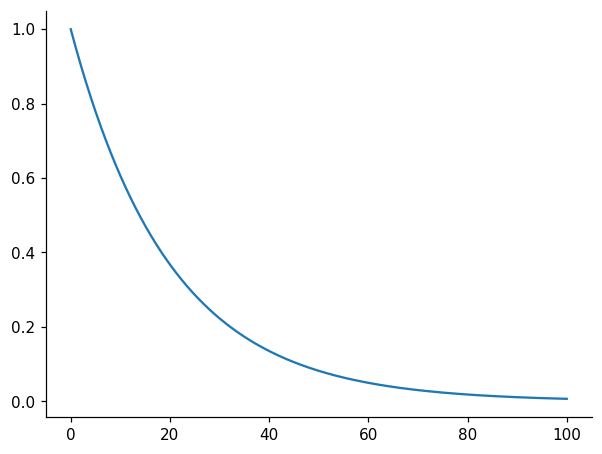

In [5]:
def theory_markov_C(T2Q, T2A):
    t = np.linspace(0, 100, 1000)
    ct = np.exp(-t/T2Q - t/T2A)
    return ct, t

# Coherence times (us)
T2Q = 39.0          # Qubit    T2*
T2A = 41.0          # Ancilla  T2*
ct, t = theory_markov_C(T2Q, T2A)
plt.plot(t, ct)

simulation of the actual interaction

In [12]:
# Single-qubit Pauli building blocks
I  = qt.qeye(2)
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()
sp = qt.sigmap()   # sigma_+  raising operator
sm = qt.sigmam()   # sigma_-  lowering operator

# Embed operator into 3-qubit space
# Qubit order: 0=Q, 1=A, 2=E
def Q(op):   return qt.tensor(op, I,  I )
def A(op):   return qt.tensor(I,  op, I )
def Env(op): return qt.tensor(I,  I,  op)

print('Q(sz) acts on 3-qubit space, dims:', Q(sz).dims)
print('A(sp) dims:', A(sp).dims)

# Show how tensor product embeds operators
print('\nsz x I (4x4):'); print(qt.tensor(sz, I))
print('\nsp x sm  (exchange coupling term):'); print(qt.tensor(sp, sm))

Q(sz) acts on 3-qubit space, dims: [[2, 2, 2], [2, 2, 2]]
A(sp) dims: [[2, 2, 2], [2, 2, 2]]

sz x I (4x4):
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]]

sp x sm  (exchange coupling term):
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [20]:
Q(sm)*Q(sp)

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [9]:
# ================================================================
#  Physical parameters from Gaikwad et al. Table I and text
# ================================================================

# Coherence times (us)
T2Q = 39.0          # Qubit    T2*
T2A = 41.0          # Ancilla  T2*

# Coupling rates (rad/us) -- 2pi * value_in_MHz
Om_QA = 2*np.pi * 0.477   # Q-A iSWAP coupling (2pi x 0.477 MHz)
Om_QE = 2*np.pi * 0.473   # Q-E iSWAP coupling (2pi x 0.473 MHz)

# E-resonator dispersive coupling
chi = 2*np.pi * 0.200     # chi/2pi = 200 kHz -> rad/us

# Empirical dephasing calibration: gamma = 1.84 * A_in^1.5  (us^-1)
gamma_calib = lambda A_in: 1.84 * A_in**1.5

# Natural decay rate of Q-A concurrence (no E coupling)
Gamma0 = 1/T2Q + 1/T2A

# Time axis for simulations (us)
tlist = np.linspace(0, 10, 400)

print(f'Gamma0 = 1/T2Q + 1/T2A = {Gamma0:.5f} us^-1')
print(f'Om_QA  = {Om_QA:.4f} rad/us')
print(f'Om_QE  = {Om_QE:.4f} rad/us')
print(f'chi    = {chi:.4f}   rad/us')
print(f'iSWAP period: 2pi/Om_QE = {2*np.pi/Om_QE:.3f} us')

Gamma0 = 1/T2Q + 1/T2A = 0.05003 us^-1
Om_QA  = 2.9971 rad/us
Om_QE  = 2.9719 rad/us
chi    = 1.2566   rad/us
iSWAP period: 2pi/Om_QE = 2.114 us


H_QE eigenvalues (rad/us):
[-4.2208 -4.2208  0.      0.      0.      0.      4.2208  4.2208]

H_QE coupling strength:  2.9719 rad/us  =  0.4730 MHz
H_QA coupling strength:  2.9971 rad/us  =  0.4770 MHz


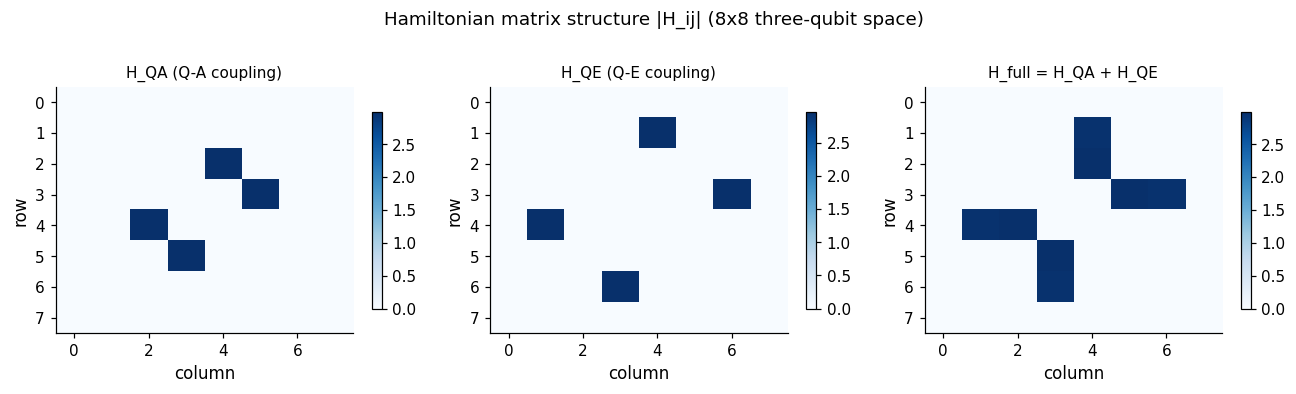

In [10]:
# Q-A iSWAP-type coupling
H_QA = Om_QA * (qt.tensor(sp, sm, I) + qt.tensor(sm, sp, I))

# Q-E iSWAP-type coupling (only active when Q-E interaction enabled)
H_QE = Om_QE * (qt.tensor(sp, I, sm) + qt.tensor(sm, I, sp))

# Full Hamiltonian
H_full = H_QA + H_QE

print('H_QE eigenvalues (rad/us):')
print(np.round(H_full.eigenenergies(), 4))

print(f'\nH_QE coupling strength:  {Om_QE:.4f} rad/us  =  {Om_QE/(2*np.pi):.4f} MHz')
print(f'H_QA coupling strength:  {Om_QA:.4f} rad/us  =  {Om_QA/(2*np.pi):.4f} MHz')

# Visualise Hamiltonian matrix structure
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
titles = ['H_QA (Q-A coupling)', 'H_QE (Q-E coupling)', 'H_full = H_QA + H_QE']
for ax, H, title in zip(axes, [H_QA, H_QE, H_full], titles):
    im = ax.imshow(np.abs(H.full()), cmap='Blues', aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('column'); ax.set_ylabel('row')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Hamiltonian matrix structure |H_ij| (8x8 three-qubit space)', y=1.01)
plt.tight_layout()
plt.show()

c_Q = sqrt(1/T2Q) * sz_Q  (diagonal of 8x8 matrix):
[ 0.16013  0.16013  0.16013  0.16013 -0.16013 -0.16013 -0.16013 -0.16013]

Dephasing rate on Q: gamma_Q = 1/T2Q = 0.02564 us^-1
Dephasing rate on A: gamma_A = 1/T2A = 0.02439 us^-1


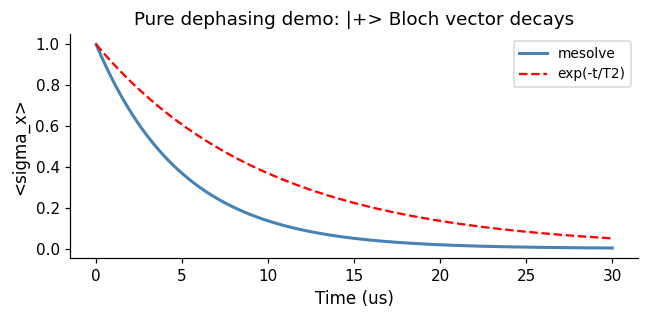

In [11]:
def build_c_ops(gamma_E=0.0):
    """
    Build Lindblad collapse operators for the 3-qubit Q-A-E system.

    Parameters
    ----------
    gamma_E : float
        Dephasing rate on environment qubit E (rad/us).
        0.0  --> non-Markovian (coherent E, no dephasing)
        ~1.0 --> onset of Markovian behaviour
        >>Om_QE --> Zeno regime

    Returns
    -------
    list of Qobj
        [c_Q, c_A] or [c_Q, c_A, c_E]
    """
    c_Q = np.sqrt(1.0/T2Q) * Q(sz)   # Q  pure dephasing
    c_A = np.sqrt(1.0/T2A) * A(sz)   # A  pure dephasing
    c_ops = [c_Q, c_A]
    if gamma_E > 0:
        c_E = np.sqrt(gamma_E) * Env(sz)   # E Lindblad dephasing
        c_ops.append(c_E)
    return c_ops

# Show the diagonal structure of the collapse operator
print('c_Q = sqrt(1/T2Q) * sz_Q  (diagonal of 8x8 matrix):')
print(np.round(np.diag(build_c_ops(0)[0].full()).real, 5))

print(f'\nDephasing rate on Q: gamma_Q = 1/T2Q = {1/T2Q:.5f} us^-1')
print(f'Dephasing rate on A: gamma_A = 1/T2A = {1/T2A:.5f} us^-1')

# Demonstrate pure dephasing on a single qubit: |+> state decoheres
rho_plus = qt.ket2dm((qt.basis(2,0) + qt.basis(2,1)).unit())
T2_demo  = 10.0
t_demo   = np.linspace(0, 30, 300)
res_demo = qt.mesolve(qt.qzero(2), rho_plus, t_demo,
                      [np.sqrt(1/T2_demo)*sz], [sx])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t_demo, res_demo.expect[0],          lw=2,  color='steelblue', label='mesolve')
ax.plot(t_demo, np.exp(-t_demo/T2_demo),     lw=1.5, color='red', ls='--', label='exp(-t/T2)')
ax.set(xlabel='Time (us)', ylabel='<sigma_x>',
       title='Pure dephasing demo: |+> Bloch vector decays')
ax.legend()
plt.tight_layout()
plt.show()

Done.


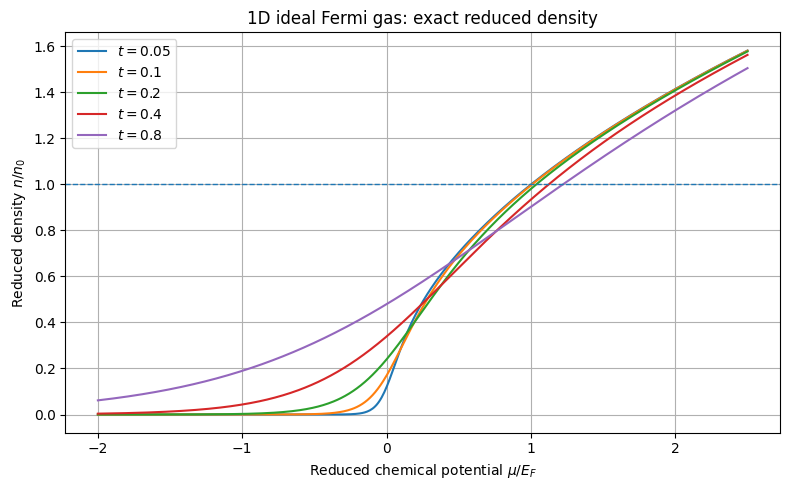

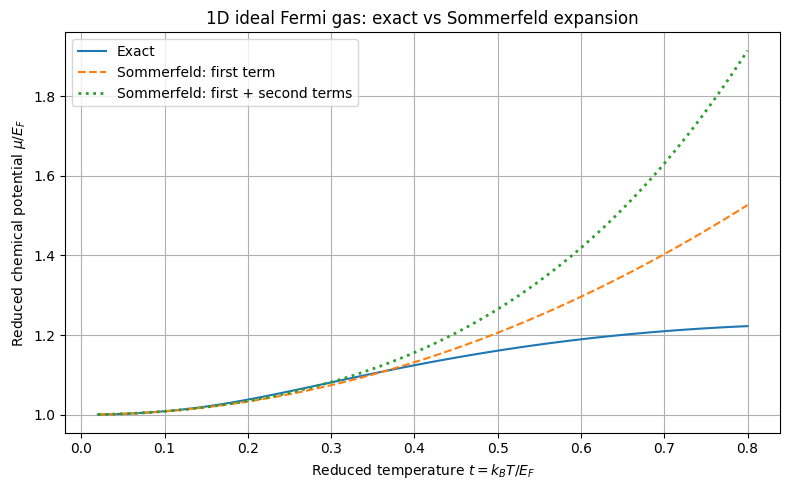

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import mpmath as mp

mp.mp.dps = 50


def n_reduced_exact(y, t):
    if t <= 0:
        raise ValueError("t must be > 0")
    val = mp.polylog(mp.mpf('0.5'), -mp.exp(mp.mpf(y) / mp.mpf(t)))
    result = -(mp.sqrt(mp.pi * t) / 2) * val
    return float(mp.re(result))


def mu_reduced_exact(t):
    if t <= 0:
        return 1.0

    def f(y):
        return n_reduced_exact(y, t) - 1.0

    guess = 1 + (np.pi**2 / 12) * t**2 + (7 * np.pi**4 / 720) * t**4

    a, b = -20.0, 5.0
    fa, fb = f(a), f(b)
    if fa * fb < 0:
        sol = root_scalar(f, bracket=[a, b], method='brentq')
        if sol.converged:
            return sol.root

    sol = root_scalar(f, x0=guess, x1=guess + 0.1, method='secant')
    if sol.converged:
        return sol.root

    raise RuntimeError(f"Root solve failed for t = {t}")


def mu_sommerfeld_first(t):
    return 1 + (np.pi**2 / 12) * t**2


def mu_sommerfeld_second(t):
    return 1 + (np.pi**2 / 12) * t**2 + (7 * np.pi**4 / 720) * t**4


# Plot 1
y_vals = np.linspace(-2.0, 2.5, 500)
t_list_density = [0.05, 0.10, 0.20, 0.40, 0.80]

plt.figure(figsize=(8, 5))
for t in t_list_density:
    n_vals = [n_reduced_exact(y, t) for y in y_vals]
    plt.plot(y_vals, n_vals, label=fr"$t={t}$")
plt.axhline(1.0, linestyle='--', linewidth=1)
plt.xlabel(r"Reduced chemical potential $\mu/E_F$")
plt.ylabel(r"Reduced density $n/n_0$")
plt.title("1D ideal Fermi gas: exact reduced density")
plt.legend()
plt.grid(True)
plt.tight_layout()


# Plot 2
t_vals = np.linspace(0.02, 0.80, 120)
mu_exact_vals = np.array([mu_reduced_exact(t) for t in t_vals])
mu_first_vals = mu_sommerfeld_first(t_vals)
mu_second_vals = mu_sommerfeld_second(t_vals)

plt.figure(figsize=(8, 5))
plt.plot(t_vals, mu_exact_vals, label="Exact")
plt.plot(t_vals, mu_first_vals, linestyle='--', label="Sommerfeld: first term")
plt.plot(t_vals, mu_second_vals, linestyle=':', linewidth=2, label="Sommerfeld: first + second terms")
plt.xlabel(r"Reduced temperature $t = k_B T / E_F$")
plt.ylabel(r"Reduced chemical potential $\mu/E_F$")
plt.title("1D ideal Fermi gas: exact vs Sommerfeld expansion")
plt.legend()
plt.grid(True)
plt.tight_layout()


print("Done.")